# Student Performance Predictor
This project predicts student performance using machine learning techniques.

In [3]:
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [6]:
# Load the student performance dataset
df = pd.read_csv('/content/sample_data/student_performance.csv', sep=';')

# Show the first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
# Check the shape of the dataset
print("Dataset shape:", df.shape)

# Show column names
print("\nColumns in the dataset:")
print(df.columns)

Dataset shape: (395, 33)

Columns in the dataset:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [8]:
# Check data types and missing values
print(df.info())

print("\nMissing values in each column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [9]:
# Create a new target column for classification
# 1 = Pass, 0 = Fail
df['pass'] = (df['G3'] >= 10).astype(int)

# Check the first 5 rows of G3 and the new target
df[['G3', 'pass']].head()

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


pass
1    265
0    130
Name: count, dtype: int64


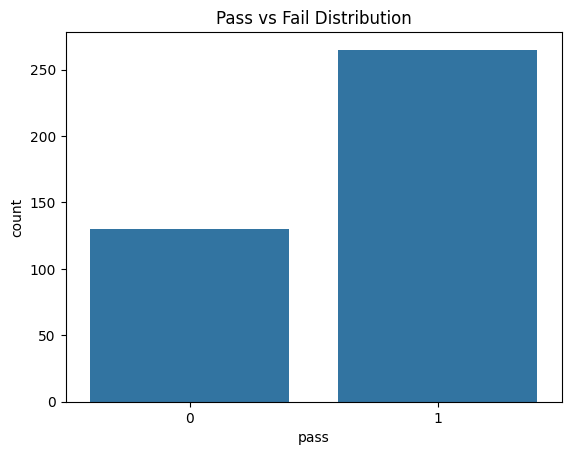

In [10]:
# Check how many students passed and failed
print(df['pass'].value_counts())

# Visualize the target distribution
sns.countplot(x='pass', data=df)
plt.title('Pass vs Fail Distribution')
plt.show()

In [11]:
# Remove the original grade columns from the features
# We remove G1, G2, and G3 to avoid leaking the answer into the model
X = df.drop(['G1', 'G2', 'G3', 'pass'], axis=1)

# Target column
y = df['pass']

# Show the first 5 rows of the features
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,4
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,2
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,4


In [12]:
# Convert categorical columns into numeric form
X_encoded = X.copy()

label_encoders = {}

for column in X_encoded.columns:
    if X_encoded[column].dtype == 'object':
        le = LabelEncoder()
        X_encoded[column] = le.fit_transform(X_encoded[column])
        label_encoders[column] = le

# Show the first 5 rows after encoding
X_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,0,0,18,1,0,0,4,4,0,4,...,1,0,0,4,3,4,1,1,3,6
1,0,0,17,1,0,1,1,1,0,2,...,1,1,0,5,3,3,1,1,3,4
2,0,0,15,1,1,1,1,1,0,2,...,1,1,0,4,3,2,2,3,3,10
3,0,0,15,1,0,1,4,2,1,3,...,1,1,1,3,2,2,1,1,5,2
4,0,0,16,1,0,1,3,3,2,2,...,1,0,0,4,3,2,1,2,5,4


In [13]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Check the shape of each split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (316, 30)
X_test shape: (79, 30)
y_train shape: (316,)
y_test shape: (79,)


In [14]:
# Train the Random Forest classification model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

In [15]:
# Evaluate the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7215189873417721


In [16]:
# Show detailed classification results
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.30      0.42        27
           1       0.72      0.94      0.82        52

    accuracy                           0.72        79
   macro avg       0.72      0.62      0.62        79
weighted avg       0.72      0.72      0.68        79

Confusion Matrix:
[[ 8 19]
 [ 3 49]]


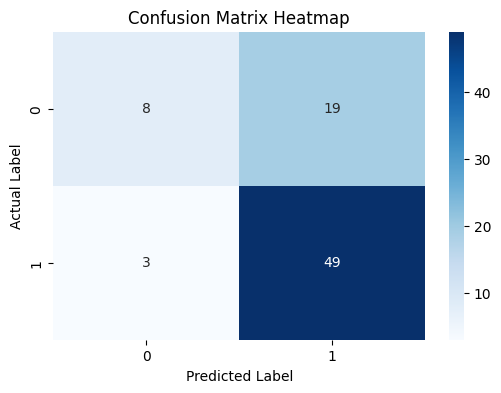

In [17]:
# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Model Result Summary

The Random Forest model achieved an accuracy of about 72%.

The model performed better at identifying students who passed than students who failed. This can be seen in the classification report, where the recall for the pass class was much higher than the recall for the fail class.

This suggests that the dataset is slightly imbalanced, and the model is more confident when predicting students who pass. A future improvement could involve tuning the model or handling class imbalance more carefully.

## Conclusion

This project showed how machine learning can be used to predict student performance based on personal, social, and academic factors.

Using a Random Forest classifier, the model achieved a moderate accuracy and performed better at identifying students who passed than those who failed.

This project highlights the importance of data preprocessing, feature encoding, model training, and evaluation when building a classification model.